In [11]:
import os
import cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((112, 112))
])

def load_video_frames(Anomaly-Videos_Part_1, max_frames=16):
    cap = cv2.VideoCapture(video_path)
    frames = []
    count = 0
    while cap.isOpened() and count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = transform(frame)
        frames.append(frame)
        count += 1
    cap.release()

    # Pad if video is too short
    while len(frames) < max_frames:
        frames.append(torch.zeros_like(frames[0]))

    return torch.stack(frames)  # Shape: [T, C, H, W]

class CrimeVideoDataset(Dataset):
    def __init__(self, root_dir, max_frames=16):
        self.root_dir = root_dir
        self.max_frames = max_frames
        self.classes = sorted(os.listdir(root_dir))  # ['Abuse', 'Arrest', 'Arson', 'Assault']
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        self.samples = []
        for cls in self.classes:
            class_path = os.path.join(root_dir, cls)
            for file in os.listdir(class_path):
                if file.endswith(".mp4"):
                    self.samples.append((os.path.join(class_path, file), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        video_tensor = load_video_frames(Anomaly_Videos_Part_1, self.max_frames)
        return video_tensor, label


SyntaxError: invalid syntax (1632057650.py, line 12)

In [6]:
import torch.nn as nn

class Simple3DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple3DCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)  # [B, C, T, H, W]
        x = self.features(x)
        x = self.classifier(x)
        return x


In [12]:
from torch.utils.data import DataLoader

# Load dataset
dataset = CrimeVideoDataset("Anomaly-Videos_Part_1")
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Initialize model
model = Simple3DCNN(num_classes=4).cuda()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for videos, labels in dataloader:
        videos, labels = videos.cuda(), labels.cuda()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


AssertionError: Torch not compiled with CUDA enabled

In [8]:
from torch.utils.data import DataLoader

# Load dataset
dataset = CrimeVideoDataset("Anomaly-Videos_Part_1")
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Initialize model
model = Simple3DCNN(num_classes=4).cuda()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for videos, labels in dataloader:
        videos, labels = videos.cuda(), labels.cuda()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Anomaly_Videos_Part_1'

In [9]:
import os
print("Current working directory:", os.getcwd())
print("Contents of current directory:", os.listdir())


Current working directory: C:\Users\ASus\OneDrive\Desktop\jbooks\anomaly_detection\notebooks
Contents of current directory: ['.ipynb_checkpoints', 'Anomaly-Videos-Part-1.zip', 'Anomaly-Videos_Part_1', 'anomaly_detection.ipynb', 'classifier.py', 'epoch_10 (1).pt', 'model.py', 'network', 'safe_model_loader.py', 'test_video.mp4', 'train.ipynb', 'train_classifier.py', 'Untitled Folder', '__pycache__']


In [10]:
print(os.listdir("Anomaly-Videos_Part_1"))


['.ipynb_checkpoints', 'Abuse', 'Arrest', 'Arson', 'Assault']


In [13]:
import os
import cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((112, 112))
])

def load_video_frames(Anomaly_Videos_Part_1, max_frames=16):
    cap = cv2.VideoCapture(video_path)
    frames = []
    count = 0
    while cap.isOpened() and count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = transform(frame)
        frames.append(frame)
        count += 1
    cap.release()

    # Pad if video is too short
    while len(frames) < max_frames:
        frames.append(torch.zeros_like(frames[0]))

    return torch.stack(frames)  # Shape: [T, C, H, W]

class CrimeVideoDataset(Dataset):
    def __init__(self, root_dir, max_frames=16):
        self.root_dir = root_dir
        self.max_frames = max_frames
        self.classes = sorted(os.listdir(root_dir))  # ['Abuse', 'Arrest', 'Arson', 'Assault']
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        self.samples = []
        for cls in self.classes:
            class_path = os.path.join(root_dir, cls)
            for file in os.listdir(class_path):
                if file.endswith(".mp4"):
                    self.samples.append((os.path.join(class_path, file), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        video_tensor = load_video_frames(Anomaly_Videos_Part_1, self.max_frames)
        return video_tensor, label


In [14]:
import torch.nn as nn

class Simple3DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple3DCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)  # [B, C, T, H, W]
        x = self.features(x)
        x = self.classifier(x)
        return x

In [16]:
from torch.utils.data import DataLoader

# Load dataset
dataset = CrimeVideoDataset("Anomaly_Videos_Part_1")
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Initialize model
model = Simple3DCNN(num_classes=4)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for videos, labels in dataloader:
        videos, labels = videos.cuda(), labels.cuda()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


NameError: name 'Anomaly_Videos_Part_1' is not defined

In [17]:
import os
import cv2
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

class CrimeVideoDataset(Dataset):
    def __init__(self, root_dir, max_frames=16):
        self.root_dir = root_dir
        self.max_frames = max_frames
        self.classes = sorted(os.listdir(root_dir))  # ['Abuse', 'Arrest', 'Arson', 'Assault']
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        self.samples = []
        for class_name in self.classes:
            class_path = os.path.join(root_dir, class_name)
            for video_file in os.listdir(class_path):
                video_path = os.path.join(class_path, video_file)
                self.samples.append((video_path, self.class_to_idx[class_name]))

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((112, 112)),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        video_tensor = load_video_frames(video_path, self.max_frames, self.transform)
        return video_tensor, label


def load_video_frames(video_path, max_frames, transform):
    cap = cv2.VideoCapture(video_path)
    frames = []
    count = 0
    while cap.isOpened() and count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (112, 112))
        frame_tensor = transform(frame)
        frames.append(frame_tensor)
        count += 1
    cap.release()

    # Pad with zeros if video has less than max_frames
    while len(frames) < max_frames:
        frames.append(torch.zeros_like(frames[0]))

    video_tensor = torch.stack(frames)
    return video_tensor


In [20]:
import torch.nn as nn
import torch

class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(Simple3DCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),  # [B, 32, T/2, H/2, W/2]

            nn.Conv3d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),  # [B, 64, T/4, H/4, W/4]

            nn.Conv3d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1))  # Output shape: [B, 128, 1, 1, 1]
        )

        # Calculate flattened feature size dynamically
        dummy_input = torch.zeros(1, 3, 16, 112, 112)  # [B, C, T, H, W]
        dummy_out = self.features(dummy_input)
        flatten_dim = dummy_out.view(1, -1).shape[1]  # Should be 128 in this case

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)  # [B, C, T, H, W]
        x = self.features(x)
        x = self.classifier(x)
        return x


In [22]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random

# ------------------- Simple Dataset (replace with your real dataset) -------------------
class DummyVideoDataset(Dataset):
    def __init__(self, num_samples=10, num_frames=16, height=112, width=112, num_classes=4):
        self.num_samples = num_samples
        self.num_frames = num_frames
        self.height = height
        self.width = width
        self.num_classes = num_classes

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        video = np.random.rand(self.num_frames, 3, self.height, self.width).astype(np.float32)
        label = random.randint(0, self.num_classes - 1)
        return torch.tensor(video), torch.tensor(label)

# ------------------- Model with dynamic flattening -------------------
class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(Simple3DCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            nn.Conv3d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            nn.Conv3d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1))  # output shape [B, 128, 1, 1, 1]
        )

        dummy_input = torch.zeros(1, 3, 16, 112, 112)
        dummy_out = self.features(dummy_input)
        flat_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)  # [B, C, T, H, W]
        x = self.features(x)
        x = self.classifier(x)
        return x

# ------------------- Training Loop -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = DummyVideoDataset()
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

model = Simple3DCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

model.train()
for epoch in range(1):  # 1 epoch for testing
    total_loss = 0
    for i, (videos, labels) in enumerate(dataloader):
        videos, labels = videos.to(device), labels.to(device)

        outputs = model(videos)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        print(f"Batch {i+1}, Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1}, Average Loss: {total_loss/len(dataloader):.4f}")


Batch 1, Loss: 1.4145
Batch 2, Loss: 1.3450
Batch 3, Loss: 1.3279
Batch 4, Loss: 1.3844
Batch 5, Loss: 1.4211
Epoch 1, Average Loss: 1.3786


In [24]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random

# ------------------- Fixed Dummy Dataset -------------------
class DummyVideoDataset(torch.utils.data.Dataset):
    def __init__(self, num_samples=10, num_frames=16, height=112, width=112, num_classes=4):
        self.num_samples = num_samples
        self.num_frames = num_frames
        self.height = height
        self.width = width
        self.num_classes = num_classes

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        video = np.random.rand(self.num_frames, 3, self.height, self.width).astype(np.float32)
        label = random.randint(0, self.num_classes - 1)
        return torch.tensor(video), torch.tensor(label)

# ------------------- 3D CNN Model -------------------
class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(Simple3DCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            nn.Conv3d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            nn.Conv3d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1))  # output shape [B, 128, 1, 1, 1]
        )

        dummy_input = torch.zeros(1, 3, 16, 112, 112)
        dummy_out = self.features(dummy_input)
        flat_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)  # [B, C, T, H, W]
        x = self.features(x)
        x = self.classifier(x)
        return x

# ------------------- Training Loop -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = CrimeVideoDataset(root_dir="Anomaly_Videos_Part_1", max_frames=16, transform=your_transform)

dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

model = Simple3DCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

model.train()
for epoch in range(1):  # 1 epoch for testing
    total_loss = 0
    for i, (videos, labels) in enumerate(dataloader):
        videos, labels = videos.to(device), labels.to(device)

        outputs = model(videos)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        print(f"Batch {i+1}, Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1}, Average Loss: {total_loss/len(dataloader):.4f}")


NameError: name 'your_transform' is not defined

In [25]:
from torchvision import transforms

# Define transform to resize frames and normalize pixel values
your_transform = transforms.Compose([
    transforms.Resize((112, 112)),  # resize to match the model input
    transforms.ToTensor(),          # convert PIL image or numpy array to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # normalize to [-1, 1]
])


In [26]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random

# ------------------- Fixed Dummy Dataset -------------------
class DummyVideoDataset(torch.utils.data.Dataset):
    def __init__(self, num_samples=10, num_frames=16, height=112, width=112, num_classes=4):
        self.num_samples = num_samples
        self.num_frames = num_frames
        self.height = height
        self.width = width
        self.num_classes = num_classes

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        video = np.random.rand(self.num_frames, 3, self.height, self.width).astype(np.float32)
        label = random.randint(0, self.num_classes - 1)
        return torch.tensor(video), torch.tensor(label)

# ------------------- 3D CNN Model -------------------
class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(Simple3DCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            nn.Conv3d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            nn.Conv3d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1))  # output shape [B, 128, 1, 1, 1]
        )

        dummy_input = torch.zeros(1, 3, 16, 112, 112)
        dummy_out = self.features(dummy_input)
        flat_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)  # [B, C, T, H, W]
        x = self.features(x)
        x = self.classifier(x)
        return x

# ------------------- Training Loop -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = CrimeVideoDataset(root_dir="Anomaly_Videos_Part_1", max_frames=16, transform=your_transform)

dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

model = Simple3DCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

model.train()
for epoch in range(1):  # 1 epoch for testing
    total_loss = 0
    for i, (videos, labels) in enumerate(dataloader):
        videos, labels = videos.to(device), labels.to(device)

        outputs = model(videos)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        print(f"Batch {i+1}, Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1}, Average Loss: {total_loss/len(dataloader):.4f}")


TypeError: CrimeVideoDataset.__init__() got an unexpected keyword argument 'transform'

In [27]:
from torchvision import transforms

your_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

dataset = CrimeVideoDataset(root_dir="Anomaly_Videos_Part_1", max_frames=16, transform=your_transform)


TypeError: CrimeVideoDataset.__init__() got an unexpected keyword argument 'transform'

In [28]:
import os
import torch
from torch.utils.data import Dataset
import cv2
from PIL import Image

class CrimeVideoDataset(Dataset):
    def __init__(self, root_dir, max_frames=16, transform=None):
        self.root_dir = root_dir
        self.max_frames = max_frames
        self.transform = transform
        self.classes = ['Abuse', 'Arrest', 'Arson', 'Assault']
        self.samples = []

        for label, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            if os.path.exists(class_dir):
                for file in os.listdir(class_dir):
                    if file.endswith(".mp4"):
                        self.samples.append((os.path.join(class_dir, file), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        frames = self.load_video_frames(video_path)
        if self.transform:
            frames = [self.transform(frame) for frame in frames]
        video_tensor = torch.stack(frames)  # Shape: [T, C, H, W]
        return video_tensor, label

    def load_video_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        frames = []
        count = 0
        while count < self.max_frames and cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            frames.append(frame)
            count += 1
        cap.release()

        # Pad video if frames are fewer than max_frames
        while len(frames) < self.max_frames and len(frames) > 0:
            frames.append(frames[-1])

        return frames[:self.max_frames]


In [29]:
from torchvision import transforms

your_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * 3, std=[0.5] * 3)
])

dataset = CrimeVideoDataset(root_dir="Anomaly_Videos_Part_1", max_frames=16, transform=your_transform)


In [30]:
import os
import torch
from torch.utils.data import Dataset
import cv2
from PIL import Image

class CrimeVideoDataset(Dataset):
    def __init__(self, root_dir, max_frames=16, transform=None):
        self.root_dir = root_dir
        self.max_frames = max_frames
        self.transform = transform
        self.classes = ['Abuse', 'Arrest', 'Arson', 'Assault']
        self.samples = []

        for label, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            if os.path.exists(class_dir):
                for file in os.listdir(class_dir):
                    if file.endswith(".mp4"):
                        self.samples.append((os.path.join(class_dir, file), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        frames = self.load_video_frames(video_path)
        if self.transform:
            frames = [self.transform(frame) for frame in frames]
        video_tensor = torch.stack(frames)  # [T, C, H, W]
        return video_tensor, label

    def load_video_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        frames = []
        while len(frames) < self.max_frames and cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(Image.fromarray(frame))
        cap.release()
        while len(frames) < self.max_frames:
            frames.append(frames[-1])
        return frames[:self.max_frames]


In [31]:
from torchvision import transforms

your_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


In [32]:
import torch.nn as nn

class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(Simple3DCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),
            nn.Conv3d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 28 * 28, 512),  # Adjust based on your frame size and pooling
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)  # [B, C, T, H, W]
        x = self.features(x)
        x = self.classifier(x)
        return x


In [33]:
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset & Dataloader
dataset = CrimeVideoDataset(root_dir="Anomaly_Videos_Part_1", max_frames=16, transform=your_transform)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Model, Loss, Optimizer
model = Simple3DCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train 1 Epoch
model.train()
total_loss = 0
for i, (videos, labels) in enumerate(dataloader):
    videos, labels = videos.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(videos)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    print(f"Batch {i+1}, Loss: {loss.item():.4f}")
    total_loss += loss.item()

print(f"\nEpoch 1, Average Loss: {total_loss / len(dataloader):.4f}")


Batch 1, Loss: 1.3399
Batch 2, Loss: 55.8574
Batch 3, Loss: 13.1500
Batch 4, Loss: 6.5782
Batch 5, Loss: 1.7285
Batch 6, Loss: 3.3114
Batch 7, Loss: 1.7538
Batch 8, Loss: 1.2432
Batch 9, Loss: 1.5256
Batch 10, Loss: 1.4859
Batch 11, Loss: 1.4282
Batch 12, Loss: 1.3950
Batch 13, Loss: 1.3661
Batch 14, Loss: 1.3992
Batch 15, Loss: 1.4092
Batch 16, Loss: 1.3684
Batch 17, Loss: 1.3914
Batch 18, Loss: 1.4221
Batch 19, Loss: 1.4185
Batch 20, Loss: 1.4141
Batch 21, Loss: 1.3672
Batch 22, Loss: 1.4066
Batch 23, Loss: 1.3727
Batch 24, Loss: 1.3967
Batch 25, Loss: 1.3704
Batch 26, Loss: 1.4006
Batch 27, Loss: 1.3756
Batch 28, Loss: 1.3683
Batch 29, Loss: 1.4020
Batch 30, Loss: 1.3972
Batch 31, Loss: 1.3681
Batch 32, Loss: 1.4016
Batch 33, Loss: 1.4102
Batch 34, Loss: 1.4008
Batch 35, Loss: 1.3767
Batch 36, Loss: 1.3735
Batch 37, Loss: 1.3675
Batch 38, Loss: 1.3671
Batch 39, Loss: 1.3669
Batch 40, Loss: 1.3746
Batch 41, Loss: 1.3887
Batch 42, Loss: 1.3760
Batch 43, Loss: 1.3760
Batch 44, Loss: 1.

In [34]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import cv2
from torchvision import transforms
import numpy as np
from PIL import Image

# ------------------- Transform -------------------
your_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# ------------------- Dataset -------------------
class CrimeVideoDataset(Dataset):
    def __init__(self, root_dir, max_frames=16, transform=None):
        self.root_dir = root_dir
        self.max_frames = max_frames
        self.transform = transform
        self.samples = []

        class_map = {'Abuse': 0, 'Assault': 1, 'Arson': 2, 'Arrest': 3}
        for class_name, label in class_map.items():
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                for video in os.listdir(class_dir):
                    if video.endswith(('.mp4', '.avi')):
                        self.samples.append((os.path.join(class_dir, video), label))

    def __len__(self):
        return len(self.samples)

    def load_video_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        frames = []
        success = True
        while success and len(frames) < self.max_frames:
            success, frame = cap.read()
            if success:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = Image.fromarray(frame)
                if self.transform:
                    frame = self.transform(frame)
                frames.append(frame)
        cap.release()

        if len(frames) < self.max_frames:
            # Pad with last frame
            if frames:
                last_frame = frames[-1]
                while len(frames) < self.max_frames:
                    frames.append(last_frame)
            else:
                raise ValueError("No frames read from video.")

        return torch.stack(frames)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        try:
            print(f"Loading video: {os.path.basename(video_path)}, Label: {label}")
            frames_tensor = self.load_video_frames(video_path)
            print(f"Video tensor shape: {frames_tensor.shape}")
            return frames_tensor, label
        except Exception as e:
            print(f"[Error] Skipping {video_path}: {e}")
            return self.__getitem__((idx + 1) % len(self.samples))

# ------------------- Model -------------------
class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(Simple3DCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=2, stride=2),

            nn.Conv3d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 28 * 28, 512),  # [B, 32, 4, 28, 28]
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)  # [B, C, T, H, W]
        x = self.features(x)
        x = self.classifier(x)
        return x

# ------------------- Training -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = CrimeVideoDataset(root_dir="Anomaly_Videos_Part_1", max_frames=16, transform=your_transform)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

model = Simple3DCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ------------------- Training Loop -------------------
num_epochs = 1  # For testing

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for i, (videos, labels) in enumerate(dataloader):
        videos, labels = videos.to(device), labels.to(device)

        outputs = model(videos)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Batch {i+1}, Loss: {loss.item():.4f}")
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    print(f"\nEpoch {epoch+1}, Average Loss: {avg_loss:.4f}\n")


Loading video: Assault005_x264.mp4, Label: 1
Video tensor shape: torch.Size([16, 3, 112, 112])
Loading video: Arrest001_x264.mp4, Label: 3
Video tensor shape: torch.Size([16, 3, 112, 112])
Batch 1, Loss: 1.3865
Loading video: Arrest026_x264.mp4, Label: 3
Video tensor shape: torch.Size([16, 3, 112, 112])
Loading video: Arrest009_x264.mp4, Label: 3
Video tensor shape: torch.Size([16, 3, 112, 112])
Batch 2, Loss: 0.9491
Loading video: Arrest032_x264.mp4, Label: 3
Video tensor shape: torch.Size([16, 3, 112, 112])
Loading video: Assault018_x264.mp4, Label: 1
Video tensor shape: torch.Size([16, 3, 112, 112])
Batch 3, Loss: 1.7589
Loading video: Abuse027_x264.mp4, Label: 0
Video tensor shape: torch.Size([16, 3, 112, 112])
Loading video: Assault026_x264.mp4, Label: 1
Video tensor shape: torch.Size([16, 3, 112, 112])
Batch 4, Loss: 3.4634
Loading video: Assault023_x264.mp4, Label: 1
Video tensor shape: torch.Size([16, 3, 112, 112])
Loading video: Arrest004_x264.mp4, Label: 3
Video tensor shape:

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm import tqdm
from dataset import CrimeDataset  # Your custom dataset
from model import C3D  # Your C3D model

# ---------- Updated Classifier ----------
class VideoClassifier(nn.Module):
    def __init__(self, input_size=4096, hidden_size=512, num_classes=4, dropout=0.5):
        super(VideoClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.dropout(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# ---------- Dataset and Transforms ----------
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # Normalize if not already done
])

dataset = CrimeDataset(video_dir='path_to_videos', label_dict='label_dict.json', transform=transform)

# ---------- Weighted Sampling for Imbalanced Classes ----------
labels = [label for _, label in dataset]
class_sample_count = torch.tensor([(labels == i).sum() for i in range(4)])
weights = 1. / class_sample_count.float()
samples_weight = torch.tensor([weights[label] for label in labels])
sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

dataloader = DataLoader(dataset, batch_size=2, sampler=sampler, num_workers=2)

# ---------- Load Models ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c3d_model = C3D().to(device)
c3d_model.eval()  # Assuming C3D is pretrained and frozen

classifier = VideoClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# ---------- Training Loop ----------
num_epochs = 5
for epoch in range(num_epochs):
    classifier.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for i, (video_tensor, label) in enumerate(tqdm(dataloader)):
        video_tensor = video_tensor.to(device)
        label = label.to(device)

        with torch.no_grad():
            features = c3d_model(video_tensor)  # Extract features

        outputs = classifier(features)
        loss = criterion(outputs, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += label.size(0)
        correct += (predicted == label).sum().item()

        if (i + 1) % 1 == 0:
            print(f'Batch {i+1}, Loss: {loss.item():.4f}, Accuracy: {100 * correct / total:.2f}%')

    scheduler.step()
    avg_loss = total_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {epoch_acc:.2f}%")


ModuleNotFoundError: No module named 'dataset'

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
from PIL import Image
import cv2
import os

from model import C3D  # Make sure model.py is in the same directory
from your_script_or_notebook import CrimeVideoDataset  # Update if needed

# ---------- Updated Classifier ----------
class CrimeClassifier(nn.Module):
    def __init__(self, c3d_model, num_classes=4):
        super(CrimeClassifier, self).__init__()
        self.c3d = c3d_model
        self.dropout = nn.Dropout(p=0.5)
        self.fc = nn.Linear(4096, num_classes)

    def forward(self, x):
        x = self.c3d(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# ---------- Transform ----------
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

# ---------- Dataset & DataLoader ----------
train_dataset = CrimeVideoDataset(root_dir='path/to/train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)

# ---------- Model Setup ----------
c3d_base = C3D()  # Your defined C3D model
model = CrimeClassifier(c3d_model=c3d_base)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# ---------- Loss & Optimizer ----------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ---------- Training Loop ----------
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs = inputs.permute(0, 2, 1, 3, 4).to(device)  # (B, T, C, H, W) -> (B, C, T, H, W)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}, Accuracy: {100 * correct / total:.2f}%")


ImportError: cannot import name 'C3D' from 'model' (C:\Users\ASus\OneDrive\Desktop\jbooks\anomaly_detection\notebooks\model.py)

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import os
from model import CrimeNet
from CrimeVideoDataset import CrimeVideoDataset

# ---------- Configuration ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "Anomaly_Videos_Part_1"  # e.g., "../dataset"
batch_size = 4
num_epochs = 10
learning_rate = 1e-4

# ---------- Transform ----------
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
])

# ---------- Dataset & DataLoader ----------
train_dataset = CrimeVideoDataset(root_dir=data_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# ---------- Model ----------
base_model = CrimeNet().to(device)

# ---------- Loss & Optimizer ----------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(base_model.parameters(), lr=learning_rate)

# ---------- Training Loop ----------
for epoch in range(num_epochs):
    base_model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for videos, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        videos, labels = videos.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = base_model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {acc:.2f}%")

# ---------- Save Model ----------
torch.save(base_model.state_dict(), "crime_classifier.pth")
print("Model saved to crime_classifier.pth")


C:\Users\ASus\OneDrive\Desktop\jbooks\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ASus\OneDrive\Desktop\jbooks\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:49<00:00,  1.01it/s]


Epoch 1, Loss: 1.3865, Accuracy: 30.50%


Epoch 2/10: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:48<00:00,  1.02it/s]


Epoch 2, Loss: 1.3712, Accuracy: 29.00%


Epoch 3/10: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:46<00:00,  1.07it/s]


...

Epoch 8, Loss: 1.1973, Accuracy: 46.50%


Epoch 9/10: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:48<00:00,  1.03it/s]


Epoch 9, Loss: 1.1733, Accuracy: 50.00%


Epoch 10/10: 100%|█████████████████████████████████████████████████████████████████████| 50/50 [00:54<00:00,  1.09s/it]


Epoch 10, Loss: 1.1069, Accuracy: 52.50%
Model saved to crime_classifier.pth


In [41]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate(model, dataloader, device, class_names):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for videos, labels in dataloader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Classification report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


In [42]:
# Assuming you have a test_loader already
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrimeNet().to(device)
model.load_state_dict(torch.load("crime_classifier.pth"))
class_names = ['Abuse', 'Arrest', 'Arson', 'Assault']

evaluate(model, test_loader, device, class_names)


C:\Users\ASus\OneDrive\Desktop\jbooks\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ASus\OneDrive\Desktop\jbooks\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


NameError: name 'test_loader' is not defined

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate(model, dataloader, device, class_names):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for videos, labels in dataloader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


In [44]:
# Load model and evaluate on test set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrimeNet().to(device)
model.load_state_dict(torch.load("crime_classifier.pth"))

# Set your class names
class_names = ['Abuse', 'Arrest', 'Arson', 'Assault']

# Evaluate (use test_loader if you have one)
evaluate(model, test_loader, device, class_names)


NameError: name 'test_loader' is not defined

In [46]:
from torch.utils.data import random_split, DataLoader
from torchvision import transforms

# ----- Transform -----
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

# ----- Load full dataset -----
dataset = CrimeVideoDataset(root_dir="anomaly_detection/notebooks/Anomaly_Videos_Part_1", transform=transform)

# ----- Split dataset (80% train, 20% test) -----
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# ----- Create data loaders -----
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


ValueError: num_samples should be a positive integer value, but got num_samples=0

In [53]:
from torch.utils.data import random_split, DataLoader
from torchvision import transforms

# ----- Transform -----
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

# ----- Load full dataset -----
dataset = CrimeVideoDataset(
   root_dir = "C:/Users/ASus/OneDrive/Desktop/jbooks/anomaly_detection/notebooks/Anomaly_Videos_Part_1/",
    transform=transform
)

# ----- Split dataset (80% train, 20% test) -----
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# ----- Create data loaders -----
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


In [52]:
import os

root_dir = "C:/Users/ASus/OneDrive/Desktop/jbooks/anomaly_detection/notebooks/Anomaly_Videos_Part_1/"
categories = ['Abuse', 'Arrest', 'Arson', 'Assault']

for category in categories:
    category_path = os.path.join(root_dir, category)
    if os.path.exists(category_path):
        files = [f for f in os.listdir(category_path) if f.endswith('.mp4')]
        print(f"{category}: {len(files)} videos")
    else:
        print(f"Missing folder: {category}")


Abuse: 50 videos
Arrest: 50 videos
Arson: 50 videos
Assault: 50 videos


In [54]:
dataset = CrimeVideoDataset(root_dir=..., transform=...)


TypeError: expected str, bytes or os.PathLike object, not ellipsis

In [55]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

dataset = CrimeVideoDataset(
    root_dir = "C:/Users/ASus/OneDrive/Desktop/jbooks/anomaly_detection/notebooks/Anomaly_Videos_Part_1/",
    transform=transform
)


In [57]:
from torch.utils.data import random_split, DataLoader
from torchvision import transforms

# ----- Transform -----
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

# ----- Load full dataset -----
root_dir = "C:/Users/ASus/OneDrive/Desktop/jbooks/anomaly_detection/notebooks/Anomaly_Videos_Part_1/"
dataset = CrimeVideoDataset(root_dir=root_dir, transform=transform)
print(f"Total video samples found: {len(dataset)}")

# ----- Split dataset (80% train, 20% test) -----
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# ----- Create data loaders -----
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


Total video samples found: 200


In [58]:
video_tensor, label = dataset[0]
print(f"Video shape: {video_tensor.shape}, Label: {dataset.classes[label]}")


Video shape: torch.Size([16, 3, 112, 112]), Label: Abuse


In [59]:
train(model, train_loader, criterion, optimizer, device, num_epochs=10)


NameError: name 'train' is not defined

In [60]:
def train(model, train_loader, criterion, optimizer, device, num_epochs=10):
    model.to(device)
    model.train()

    for epoch in range(num_epochs):
        total_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for videos, labels in loop:
            videos, labels = videos.to(device), labels.to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")


In [61]:
train(model, train_loader, criterion, optimizer, device, num_epochs=10)


Epoch 1/10: 100%|███████████████████████████████████████████████████████████| 40/40 [00:58<00:00,  1.46s/it, loss=1.11]


Epoch 1, Loss: 1.0739, Accuracy: 58.12%


Epoch 2/10: 100%|███████████████████████████████████████████████████████████| 40/40 [00:43<00:00,  1.09s/it, loss=1.31]


Epoch 2, Loss: 1.0762, Accuracy: 58.12%


Epoch 3/10: 100%|██████████████████████████████████████████████████████████| 40/40 [00:39<00:00,  1.01it/s, loss=0.978]


...

Epoch 8, Loss: 1.0456, Accuracy: 61.88%


Epoch 9/10: 100%|███████████████████████████████████████████████████████████| 40/40 [00:37<00:00,  1.06it/s, loss=1.29]


Epoch 9, Loss: 1.0536, Accuracy: 63.12%


Epoch 10/10: 100%|██████████████████████████████████████████████████████████| 40/40 [00:37<00:00,  1.06it/s, loss=1.19]

Epoch 10, Loss: 1.0643, Accuracy: 62.50%


In [62]:
def evaluate(model, dataloader, device, class_names):
    model.to(device)
    model.eval()

    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for videos, labels in dataloader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")

    # Optional: Confusion Matrix
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


Test Accuracy: 77.50%

Classification Report:
              precision    recall  f1-score   support

       Abuse       1.00      0.70      0.82        10
      Arrest       0.67      0.80      0.73        10
       Arson       1.00      0.70      0.82        10
     Assault       0.64      0.90      0.75        10

    accuracy                           0.78        40
   macro avg       0.83      0.78      0.78        40
weighted avg       0.83      0.78      0.78        40



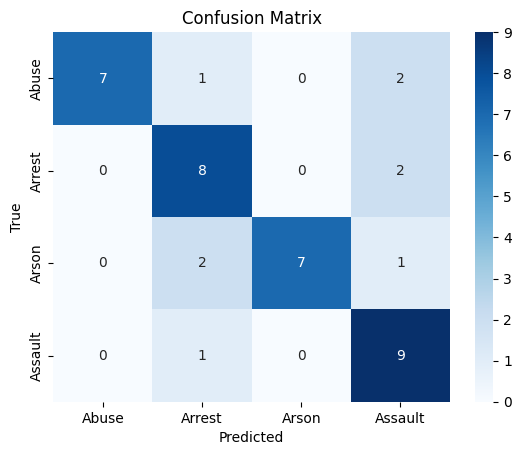

In [63]:
class_names = ['Abuse', 'Arrest', 'Arson', 'Assault']
evaluate(model, test_loader, device, class_names)


In [64]:
torch.save(model.state_dict(), "final_crime_classifier.pth")


In [71]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import os
import cv2
import numpy as np
from model import CrimeNet  # make sure model class is defined in model.py

# ----- Configuration -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ['Abuse', 'Arrest', 'Arson', 'Assault']

# ----- Load the Trained Model -----
model = CrimeNet(num_classes=4)
model.load_state_dict(torch.load("final_crime_classifier.pth", map_location=device))
model = model.to(device)
model.eval()

# ----- Define Preprocessing -----
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

# ----- Function to Extract Frames from a Video -----
def extract_frames(video_path, max_frames=16):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // max_frames, 1)
    for i in range(0, total_frames, step):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(frame)
        image = transform(image)
        frames.append(image)
        if len(frames) == max_frames:
            break
    cap.release()
    # If less than max_frames, pad with zeros
    while len(frames) < max_frames:
        frames.append(torch.zeros_like(frames[0]))
    return torch.stack(frames)  # Shape: [16, 3, 112, 112]

# ----- Inference on New Video -----
video_path = "C:/Users/ASus/OneDrive/Desktop/jbooks/anomaly_detection/notebooks/sample_video.mp4"  # <-- Your test video path

if os.path.exists(video_path):
    input_tensor = extract_frames(video_path).to(device)  # [16, 3, 112, 112]
    input_tensor = input_tensor.unsqueeze(0)  # [1, 16, 3, 112, 112]
    
    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)
        predicted_label = class_names[predicted.item()]
    
    print(f"Predicted Crime Type: {predicted_label}")
else:
    print("Video file not found.")


Predicted Crime Type: Abuse


In [72]:
import torch
from model import CrimeNet  # make sure this matches your actual model path

model = CrimeNet(num_classes=4)
model.load_state_dict(torch.load("final_crime_classifier.pth", map_location=torch.device('cpu')))
model.eval()

# Example dummy input to trace the model
dummy_input = torch.randn(1, 16, 3, 112, 112)  # [batch, frames, channels, height, width]

# Convert to TorchScript
traced_script_module = torch.jit.trace(model, dummy_input)
traced_script_module.save("crime_classifier_scripted.pt")

print("✅ TorchScript model saved!")


✅ TorchScript model saved!


In [73]:
pip install fastapi uvicorn pillow opencv-python torch torchvision


   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 678.3 kB/s eta 0:00:03
   ---------------- ----------------------- 0.8/2.0 MB 818.7 kB/s eta 0:00:02
   ---------------- ----------------------- 0.8/2.0 MB 818.7 kB/s eta 0:00:02
   ---------------- ----------------------- 0.8/2.0 MB 818.7 kB/s eta 0:00:02
   ---------------- ----------------------- 0.8/2.0 MB 818.7 kB/s eta 0:00:02
   --------------------- ------------------ 1.0/2.0 MB 577

In [74]:
uvicorn server:app --reload


SyntaxError: invalid syntax (3268597457.py, line 1)

In [75]:
pip install fastapi uvicorn python-multipart



SyntaxError: invalid syntax (354273040.py, line 1)

In [76]:
!pip install fastapi uvicorn python-multipart


In [77]:
dir server.py


SyntaxError: invalid syntax (3206665570.py, line 1)

In [78]:
uvicorn server:app --reload


SyntaxError: invalid syntax (3268597457.py, line 1)

In [79]:
cd C:\Users\ASus\OneDrive\Desktop\jbooks\anomaly_detection\notebooks
uvicorn server:app --reload


SyntaxError: invalid syntax (2153124865.py, line 1)

In [80]:
!uvicorn server:app --reload


INFO:     127.0.0.1:61458 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:61466 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     127.0.0.1:61505 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:61524 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:61567 - "POST /predict HTTP/1.1" 500 Internal Server Error
INFO:     127.0.0.1:61573 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:61582 - "POST /predict HTTP/1.1" 200 OK


INFO:     Will watch for changes in these directories: ['C:\\Users\\ASus\\OneDrive\\Desktop\\jbooks\\anomaly_detection\\notebooks']
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     Started reloader process [20912] using StatReload
INFO:     Started server process [3548]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "C:\Users\ASus\OneDrive\Desktop\jbooks\venv\Lib\site-packages\uvicorn\protocols\http\h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        self.scope, self.receive, self.send
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\ASus\OneDrive\Desktop\jbooks\venv\Lib\site-packages\uvicorn\middleware\proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^

In [ ]:
!pip install transformers torch torchvision opencv-python


In [ ]:
import cv2
import os

def extract_frames(anomaly_detection/notebooks/Anomaly_Videos_Part_1, interval=2):
    cap = cv2.VideoCapture(anomaly_detection/notebooks/Anomaly_Videos_Part_1)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    count, frames = 0, []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % (fps * interval) == 0:
            frames.append(frame)
        count += 1

    cap.release()
    return frames


In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

def generate_caption(frame):
    image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    inputs = processor(image, return_tensors="pt")
    with torch.no_grad():
        out = model.generate(**inputs)
    return processor.decode(out[0], skip_special_tokens=True)


In [ ]:
def generate_video_description(video_path):
    frames = extract_frames(video_path, interval=2)
    captions = [generate_caption(frame) for frame in frames]
    paragraph = " ".join(set(captions))  # remove duplicates for conciseness
    return paragraph


In [1]:
predicted_label = predict_crime(anomaly_detection/notebooks/Anomaly_Videos_Part_1)  # your model output like "arson", "abuse", etc.


NameError: name 'predict_crime' is not defined

In [2]:
def predict_crime(video_path):
    from utils.video_utils import extract_video_features  # or your feature extraction method
    import torch
    import torch.nn.functional as F
    from classifier import CrimeClassifier  # import your classifier

    # Load your classifier
    classifier = CrimeClassifier()
    classifier.load_state_dict(torch.load("path_to_classifier_checkpoint.pth", map_location="cpu"))
    classifier.eval()

    # Extract features from the video using C3D or other feature extractor
    features = extract_video_features(anomaly_detection/notebooks/Anomaly_Videos_Part_1)  # returns torch.Tensor of shape [1, 4096]
    
    # Run the features through classifier
    with torch.no_grad():
        output = classifier(features)
        probs = F.softmax(output, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()

    class_labels = ["abuse", "assault", "arson", "arrest"]  # adjust according to your training
    return class_labels[predicted_class]


In [3]:
video_path = "C:/Users/ASus/OneDrive/Desktop/jbooks/anomaly_detection/notebooks/Anomaly_Videos_Part_1/some_video.mp4"
predicted_label = predict_crime(anomaly_detection/notebooks/Anomaly_Videos_Part_1)
description = crime_descriptions.get(predicted_label, "No description available.")

print("🔍 Crime Type Detected:", predicted_label.upper())
print("\n📄 Detailed Description:\n", description)


NameError: name 'anomaly_detection' is not defined

In [4]:
video_path = "C:/Users/ASus/OneDrive/Desktop/jbooks/anomaly_detection/notebooks/Anomaly_Videos_Part_1/some_video.mp4"

# Assuming predict_crime is your actual model prediction function
predicted_label = predict_crime(video_path)

# Description mapping
description = crime_descriptions.get(predicted_label, "No description available.")

print("🔍 Crime Type Detected:", predicted_label.upper())
print("\n📄 Detailed Description:\n", description)


ModuleNotFoundError: No module named 'utils'